# Step 1
Establish one shared baseline dataset pipeline for Section 3.1 Data Description

## Success criterion for Step 1
Orange3 and Jupyter must produce the same row count, same column count, and the same validation numbers before moving to the next report section.

In [22]:
# Core imports for Step 1 pipeline
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Reusable paths
DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [23]:
# Load source datasets
train_set = pd.read_csv(DATA_DIR / "train.csv", sep="|")
items_set = pd.read_csv(DATA_DIR / "items.csv", sep="|")

# Minimal schema validation for reproducibility
required_train_cols = {"pid", "click", "basket", "order", "price"}
required_items_cols = {"pid", "manufacturer", "rrp"}

missing_train_cols = required_train_cols - set(train_set.columns)
missing_items_cols = required_items_cols - set(items_set.columns)
if missing_train_cols:
    raise ValueError(f"train.csv missing required columns: {sorted(missing_train_cols)}")
if missing_items_cols:
    raise ValueError(f"items.csv missing required columns: {sorted(missing_items_cols)}")

print("Train shape:", train_set.shape)
print("Items shape:", items_set.shape)
print("Unique pids in train:", train_set["pid"].nunique())
print("Unique pids in items:", items_set["pid"].nunique())

Train shape: (2756003, 11)
Items shape: (22035, 11)
Unique pids in train: 21928
Unique pids in items: 22035


In [24]:
# Ensure join key uniqueness on the right table before merge
if not items_set["pid"].is_unique:
    duplicate_pid_count = int(items_set["pid"].duplicated().sum())
    raise ValueError(
        f"items.csv contains {duplicate_pid_count} duplicated pid values; expected unique pid for m:1 merge"
    )

# Left join on pid to enrich train data with item attributes
# Learning: validate="m:1" enforces that each pid in train_set matches at most one pid in items_set, ensuring no unintended duplication of rows.
train_item_set = train_set.merge(items_set, on="pid", how="left", validate="m:1")

# Validation checks
# Learning: isna vs isnull - both methods are equivalent for pandas DataFrames; isna is an alias for isnull. Using isna() for consistency with pandas documentation and readability.
row_count = int(train_item_set.shape[0])
column_count = int(train_item_set.shape[1])
missing_values = train_item_set.isna().sum().sort_values(ascending=False)

# Strict mutual exclusivity: exactly one of click/basket/order must be 1
action_cols = ["click", "basket", "order"]
action_sum = train_item_set[action_cols].sum(axis=1)
mutual_exclusive_exact = bool((action_sum == 1).all())
violating_rows = int((action_sum != 1).sum())

# Expected parity values from Step 1 baseline
expected = {
    "row_count": 2756003,
    "column_count": 21,
    "mutual_exclusive_exact": True,
}
parity_ok = (
    row_count == expected["row_count"]
    and column_count == expected["column_count"]
    and mutual_exclusive_exact == expected["mutual_exclusive_exact"]
)
if not parity_ok:
    raise AssertionError(
        "Step 1 parity check failed. Review source data and merge logic before continuing."
    )

# Persist canonical Step 1 artifacts
merged_out = PROCESSED_DIR / "step1_merged_baseline.csv"
missing_out = PROCESSED_DIR / "step1_missing_values.csv"
summary_out = PROCESSED_DIR / "step1_validation_summary.json"

train_item_set.to_csv(merged_out, index=False)
missing_report = missing_values.rename_axis("column").reset_index(name="missing_count")
missing_report.to_csv(missing_out, index=False)

summary_payload = {
    "row_count": row_count,
    "column_count": column_count,
    "mutual_exclusive_exact": mutual_exclusive_exact,
    "violating_rows": violating_rows,
    "parity_ok": parity_ok,
    "expected": expected,
    "artifacts": {
        "merged": str(merged_out),
        "missing_values": str(missing_out),
        "summary": str(summary_out),
    },
}
with open(summary_out, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

print("Row count:", row_count)
print("Column count:", column_count)
print("Rows violating action exclusivity:", violating_rows)
print("Click/basket/order mutual exclusivity (exactly one):", mutual_exclusive_exact)
print("Step 1 parity with baseline:", parity_ok)
print("\nTop missing values:")
print(missing_values.head(10))
print("\nValidation summary:")
print(json.dumps(summary_payload, indent=2))

Row count: 2756003
Column count: 21
Rows violating action exclusivity: 0
Click/basket/order mutual exclusivity (exactly one): True
Step 1 parity with baseline: True

Top missing values:
campaignIndex      2287968
pharmForm           194124
competitorPrice     100687
category             87394
lineID                   0
availability             0
adFlag                   0
pid                      0
day                      0
price                    0
dtype: int64

Validation summary:
{
  "row_count": 2756003,
  "column_count": 21,
  "mutual_exclusive_exact": true,
  "violating_rows": 0,
  "parity_ok": true,
  "expected": {
    "row_count": 2756003,
    "column_count": 21,
    "mutual_exclusive_exact": true
  },
  "artifacts": {
    "merged": "data/processed/step1_merged_baseline.csv",
    "missing_values": "data/processed/step1_missing_values.csv",
    "summary": "data/processed/step1_validation_summary.json"
  }
}


=== DATASET OVERVIEW ===
train_set: rows=2,756,003, cols=11
items_set: rows=22,035, cols=11
train_item_set: rows=2,756,003, cols=21

=== ACTION DISTRIBUTION ===
          count  rate_percent
click   1582827         57.43
basket   468086         16.98
order    705090         25.58

=== ACTION CONSISTENCY CHECK ===
Rows with exactly one action: 2756003
Rows violating exclusivity: 0
mutual_exclusive_exact: True

=== MISSING VALUES (TOP 10, MERGED) ===
campaignIndex      2287968
pharmForm           194124
competitorPrice     100687
category             87394
lineID                   0
availability             0
adFlag                   0
pid                      0
day                      0
price                    0
dtype: int64

=== NUMERIC SUMMARY (TRAIN) ===
                   mean     std   min    50%     max
day              49.921  25.295  1.00  50.00   92.00
availability      1.111   0.392  1.00   1.00    4.00
competitorPrice  12.773  12.753  0.00   8.99  264.59
price            13

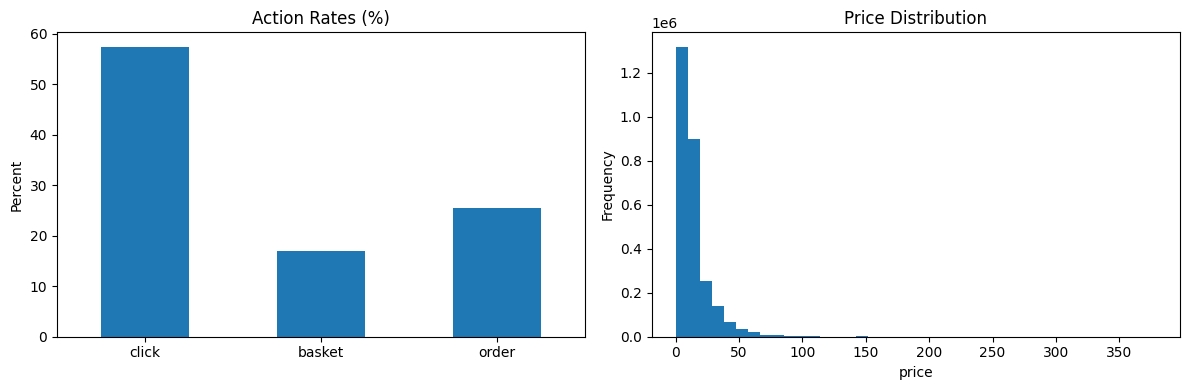

In [25]:
# Focused exploratory summary for Section 3.1 reporting
def describe_numeric(df: pd.DataFrame, candidate_cols: list[str]) -> pd.DataFrame:
    available = [c for c in candidate_cols if c in df.columns]
    if not available:
        return pd.DataFrame()
    return df[available].describe().T[["mean", "std", "min", "50%", "max"]].round(3)

train_num_cols = ["day", "availability", "competitorPrice", "price", "revenue"]
items_num_cols = ["rrp", "salesIndex", "genericProduct", "category"]

print("=== DATASET OVERVIEW ===")
print(f"train_set: rows={train_set.shape[0]:,}, cols={train_set.shape[1]}")
print(f"items_set: rows={items_set.shape[0]:,}, cols={items_set.shape[1]}")
print(f"train_item_set: rows={train_item_set.shape[0]:,}, cols={train_item_set.shape[1]}")

print("\n=== ACTION DISTRIBUTION ===")
action_counts = train_set[action_cols].sum()
action_rates = (train_set[action_cols].mean() * 100).round(2)
print(pd.DataFrame({"count": action_counts, "rate_percent": action_rates}))

print("\n=== ACTION CONSISTENCY CHECK ===")
print("Rows with exactly one action:", int((action_sum == 1).sum()))
print("Rows violating exclusivity:", int((action_sum != 1).sum()))
print("mutual_exclusive_exact:", mutual_exclusive_exact)

print("\n=== MISSING VALUES (TOP 10, MERGED) ===")
print(missing_values.head(10))

print("\n=== NUMERIC SUMMARY (TRAIN) ===")
train_summary = describe_numeric(train_set, train_num_cols)
print(train_summary if not train_summary.empty else "No requested train numeric columns available.")

print("\n=== NUMERIC SUMMARY (ITEMS) ===")
items_summary = describe_numeric(items_set, items_num_cols)
print(items_summary if not items_summary.empty else "No requested items numeric columns available.")

print("\n=== PID COVERAGE ===")
train_pids = set(train_set["pid"].unique())
item_pids = set(items_set["pid"].unique())
matched = len(train_pids & item_pids)
coverage = (matched / len(train_pids) * 100) if train_pids else 0.0
print(f"Unique pids in train_set: {len(train_pids):,}")
print(f"Unique pids in items_set: {len(item_pids):,}")
print(f"Matched unique pids: {matched:,} ({coverage:.2f}% of train pids)")

# Quick visual checks
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

action_rates.plot(kind="bar", ax=axes[0], title="Action Rates (%)")
axes[0].set_ylabel("Percent")
axes[0].tick_params(axis="x", rotation=0)

train_set["price"].plot(kind="hist", bins=40, ax=axes[1], title="Price Distribution")
axes[1].set_xlabel("price")

plt.tight_layout()
plt.show()